# 04 — Approach I: selected Leiden + manual annotation (interactive)
Choose the resolution, inspect top genes and known markers, edit the cluster mapping, and save only when satisfied.

In [2]:
# ============================================================
# Dataset_02 CosMx — shared Jupyter initialization
# ============================================================
from pathlib import Path
import sys, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scanpy as sc

CURRENT_DIR = Path.cwd().resolve()

def find_project_root(start: Path) -> Path:
    """Find the nearest parent containing both src/ and data/."""
    for candidate in [start, *start.parents]:
        if (candidate / "src").is_dir() and (candidate / "data").is_dir():
            return candidate
    raise FileNotFoundError(
        f"Could not locate project root from {start}. "
        "Expected a parent containing src/ and data/."
    )

PROJECT_ROOT = find_project_root(CURRENT_DIR)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

RAW_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
SPATIAL_DIR = PROJECT_ROOT / "data" / "spatial"
RESULTS_DIR = PROJECT_ROOT / "results"
CONFIG_DIR = PROJECT_ROOT / "config"

sc.settings.verbosity = 2

print("=" * 70)
print("Dataset_02 CosMx Jupyter environment")
print("=" * 70)
print("Notebook directory :", CURRENT_DIR)
print("Project root       :", PROJECT_ROOT)
print("Python             :", sys.executable)
print("src exists         :", (PROJECT_ROOT / "src").exists())
print("raw data exists    :", RAW_DIR.exists())
print("processed exists   :", PROCESSED_DIR.exists())
print("spatial exists     :", SPATIAL_DIR.exists())


Dataset_02 CosMx Jupyter environment
Notebook directory : /research/rgs01/home/clusterHome/jqu/activities/learning/BioHackathon/BioHackathon-2026/Dataset_02_CosMx_revised/Dataset_02_CosMx_revised/jupyter-2
Project root       : /research/rgs01/home/clusterHome/jqu/activities/learning/BioHackathon/BioHackathon-2026/Dataset_02_CosMx_revised/Dataset_02_CosMx_revised
Python             : /home/jqu/.conda/envs/spatialdata/bin/python
src exists         : True
raw data exists    : True
processed exists   : True
spatial exists     : True


In [3]:
from config.markers import MARKER_PANEL
from src.plotting import plot_umap_annotation

# ============================================================
# Select Leiden-sweep input and resolution — EDIT HERE
# ============================================================
USE_SWEEP_VARIANT = False
SWEEP_TAG = "mad3_interactive_pcs30_nn15"
SELECTED_RESOLUTION = 0.6

SWEEP_VARIANT = RESULTS_DIR / "FOV46" / "leiden_variants" / SWEEP_TAG / f"GSM9046088_FOV46_leiden_sweep_{SWEEP_TAG}.h5ad"
SWEEP_PRODUCTION = RESULTS_DIR / "FOV46" / "GSM9046088_FOV46_leiden_sweep.h5ad"
SWEEP_INPUT = SWEEP_VARIANT if USE_SWEEP_VARIANT else SWEEP_PRODUCTION

print("Sweep input:", SWEEP_INPUT)
print("Exists     :", SWEEP_INPUT.exists())
if not SWEEP_INPUT.exists():
    raise FileNotFoundError(SWEEP_INPUT)

a = sc.read_h5ad(SWEEP_INPUT)
key = f"leiden_r{SELECTED_RESOLUTION:g}"
if key not in a.obs:
    raise KeyError(f"{key} not found; available: {[x for x in a.obs if x.startswith('leiden_r')]}")
a.obs["leiden"] = a.obs[key].astype("category")
print("Selected resolution:", SELECTED_RESOLUTION)
print(a.obs["leiden"].value_counts().sort_index())


Sweep input: /research/rgs01/home/clusterHome/jqu/activities/learning/BioHackathon/BioHackathon-2026/Dataset_02_CosMx_revised/Dataset_02_CosMx_revised/results/FOV46/GSM9046088_FOV46_leiden_sweep.h5ad
Exists     : True
Selected resolution: 0.6
leiden
0    377
1    242
2    141
3    137
4     24
5     17
Name: count, dtype: int64


ranking genes
    finished (0:00:00)


,group,names,scores,logfoldchanges,pvals_adj
0,0,IGHG1,17.453619,1.673616,3.231004e-65
1,0,IGHG2,16.342541,2.153990,1.638678e-57
2,0,IGKC,16.257982,1.219864,4.902300e-57
3,0,MZB1,11.245230,2.732463,2.222353e-27
4,0,XBP1,8.186818,1.462670,1.166184e-14
5,0,IGHM,6.062129,1.609525,2.633941e-08
6,0,JCHAIN,5.842372,1.835156,9.028536e-08
7,0,LPAR5,5.471440,1.644501,6.662602e-07
8,0,MPO,4.761653,1.573225,2.258982e-05
9,0,IRF4,4.062437,1.489082,4.335992e-04


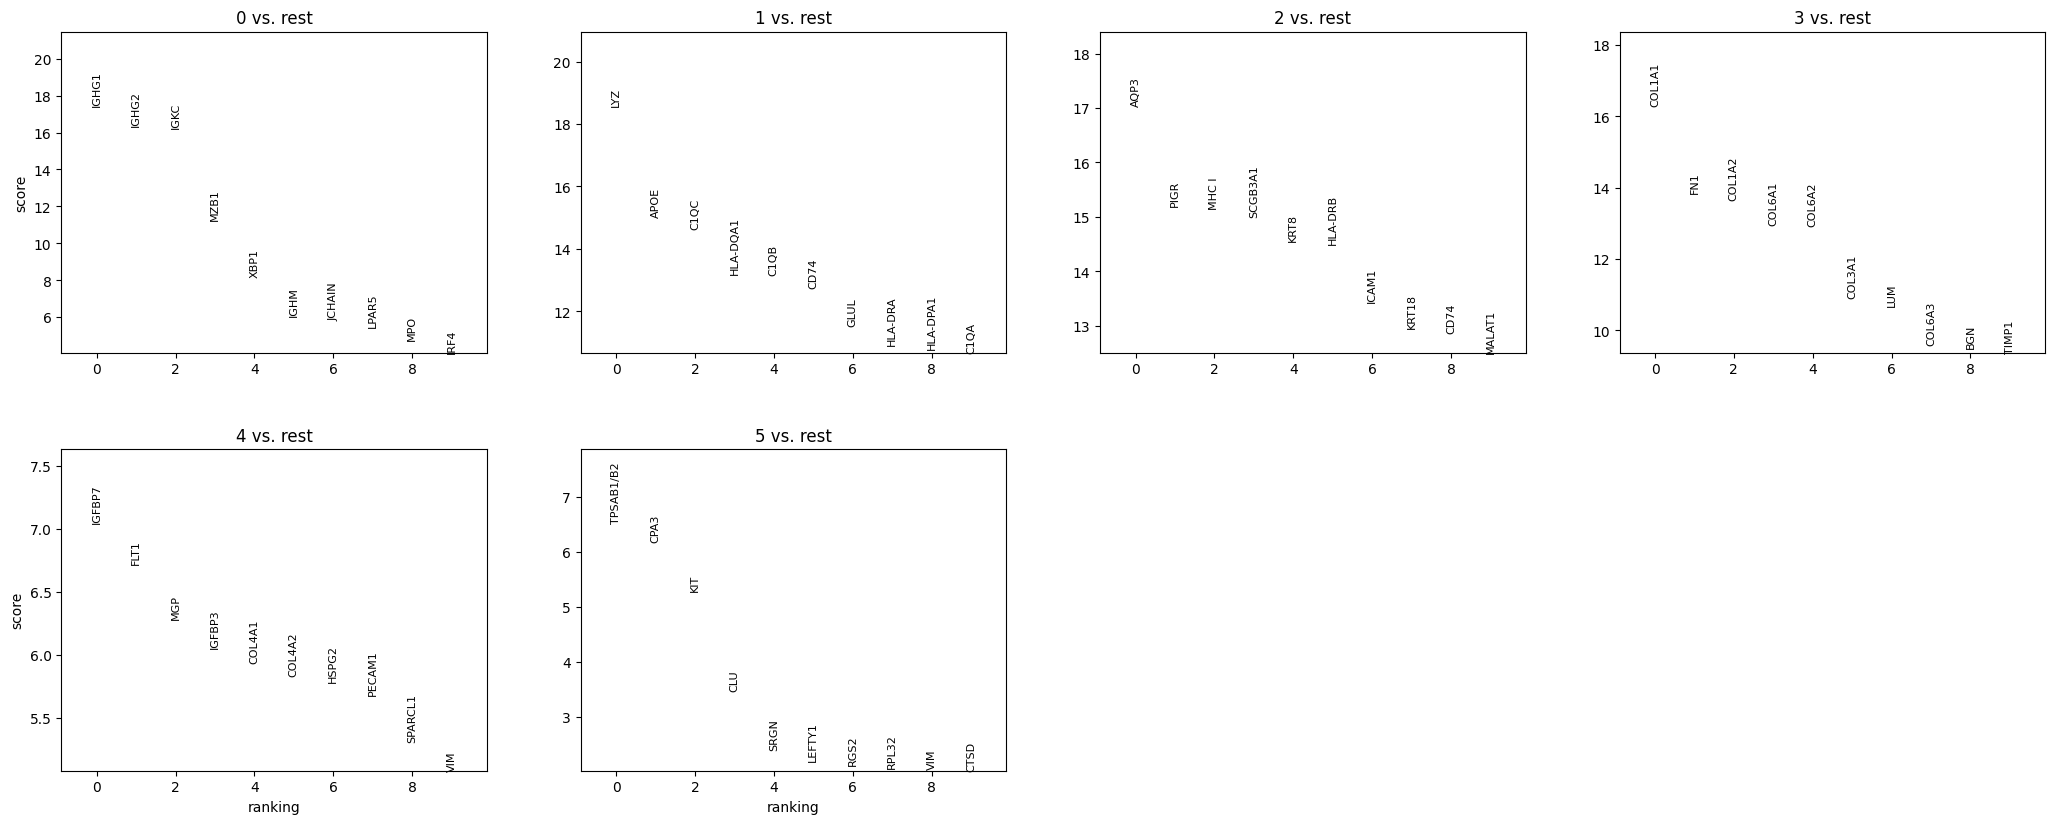

In [4]:
# Recompute selected-resolution markers and show top genes.
rank_key="rank_genes_groups_leiden_selected"
sc.tl.rank_genes_groups(a,groupby="leiden",method="wilcoxon",use_raw=True,pts=True,key_added=rank_key)
markers=sc.get.rank_genes_groups_df(a,group=None,key=rank_key)
top10=(markers.sort_values(["group","scores"],ascending=[True,False]).groupby("group",observed=True,sort=False).head(10))
display(top10[["group","names","scores","logfoldchanges","pvals_adj"]])
sc.pl.rank_genes_groups(a,key=rank_key,n_genes=10,sharey=False)

    using 'X_pca' with n_pcs = 30
Storing dendrogram info using `.uns['dendrogram_leiden']`
categories: 0, 1, 2, etc.
var_group_labels: Epithelial, AT1, Tumor_epithelial, etc.


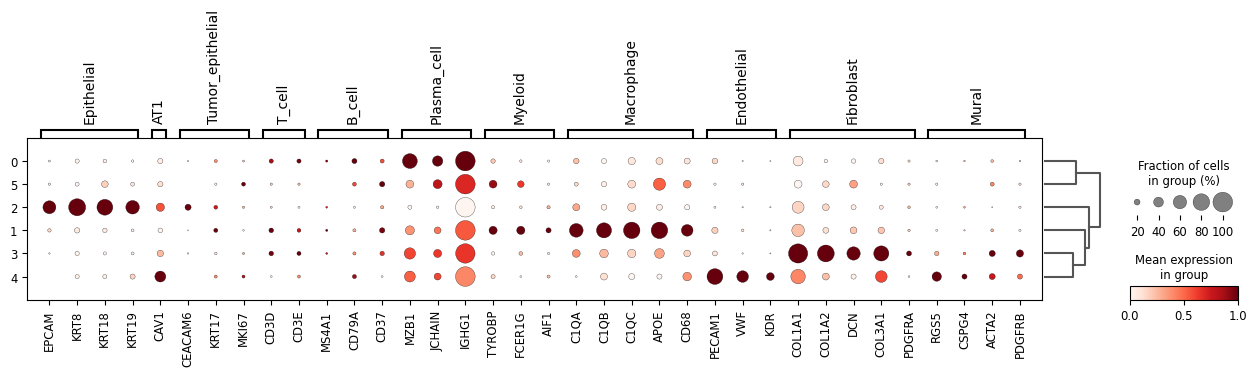

In [5]:
# Known marker-panel dotplot.
present={ct:[g for g in genes if g in a.raw.var_names] for ct,genes in MARKER_PANEL.items()}
present={ct:g for ct,g in present.items() if g}
sc.pl.dotplot(a,present,groupby="leiden",use_raw=True,standard_scale="var",dendrogram=True)

## Manual cluster → cell type mapping
Edit this dictionary based on top genes + marker panel + UMAP + spatial localization. Every cluster must be assigned before saving.

In [8]:
CLUSTER_ANNOTATIONS = {
    # change in different context
    "0": "Plasma_cell",
    "1": "Macrophage",
    "2": "Epithelial",
    "3": "Fibroblast",
    "4": "Endothelial",
    "5": "Plasma_cell",
}

clusters = sorted(a.obs["leiden"].astype(str).unique())

missing = [
    c for c in clusters
    if c not in CLUSTER_ANNOTATIONS
]

print("Clusters:", clusters)
print("Missing annotations:", missing)

Clusters: ['0', '1', '2', '3', '4', '5']
Missing annotations: []


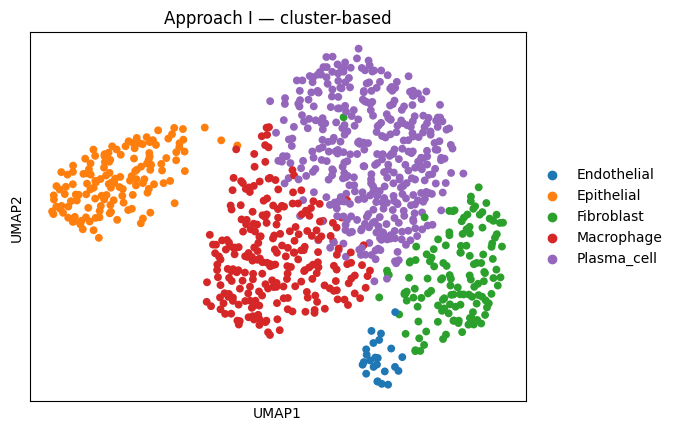

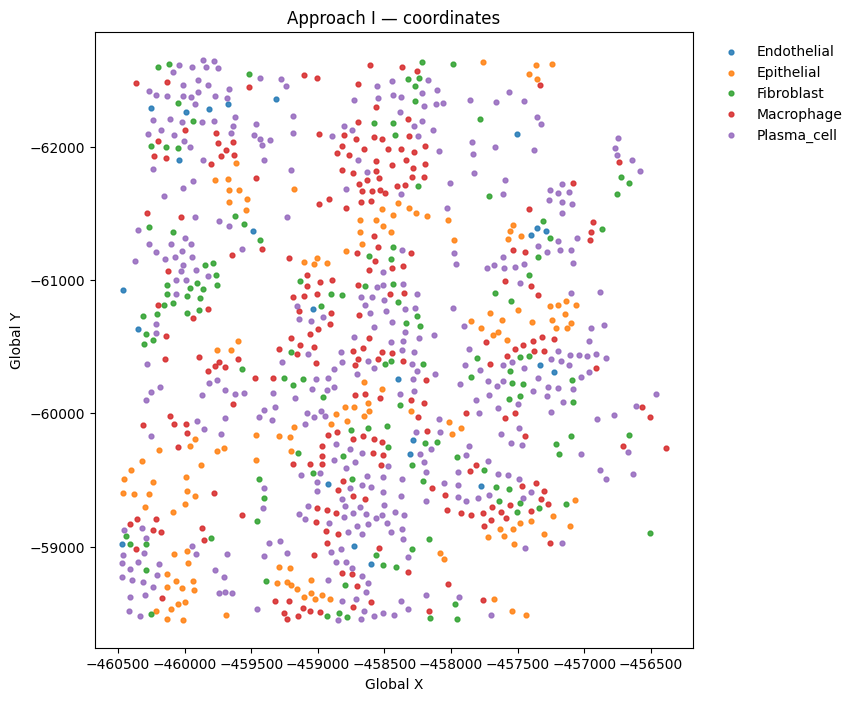

In [9]:
# Apply only when mapping is complete.
if missing:
    print("Edit CLUSTER_ANNOTATIONS first; annotation not applied.")
else:
    a.obs["cell_type_scanpy"]=pd.Categorical(a.obs["leiden"].astype(str).map(CLUSTER_ANNOTATIONS))
    sc.pl.umap(a,color="cell_type_scanpy",frameon=True,legend_loc="right margin",title="Approach I — cluster-based")
    xy=np.asarray(a.obsm["spatial"]); lab=a.obs["cell_type_scanpy"]
    fig,ax=plt.subplots(figsize=(8,8))
    for cat in lab.cat.categories:
        m=lab.astype(str).to_numpy()==str(cat); ax.scatter(xy[m,0],xy[m,1],s=12,label=str(cat),alpha=.85)
    ax.set_aspect("equal");ax.invert_yaxis();ax.set_xlabel("Global X coordinate (px)");ax.set_ylabel("Global Y coordinate (px)")
    ax.legend(bbox_to_anchor=(1.02,1),loc="upper left",frameon=False);ax.set_title("Approach I — coordinates");plt.show()

In [10]:
# ============================================================
# Versioned Approach-I output — EDIT HERE
# ============================================================
SAVE_APPROACH_I = False
APPROACH_I_TAG = f"r{SELECTED_RESOLUTION:g}_manual"
APPROACH_I_OUTPUT_DIR = RESULTS_DIR / "FOV46" / "approach_i_variants" / APPROACH_I_TAG
APPROACH_I_OUTPUT_FILE = APPROACH_I_OUTPUT_DIR / f"GSM9046088_FOV46_approach_i_{APPROACH_I_TAG}.h5ad"

print("APPROACH_I_TAG    :", APPROACH_I_TAG)
print("SAVE_APPROACH_I   :", SAVE_APPROACH_I)
print("Output directory  :", APPROACH_I_OUTPUT_DIR)
print("Output filename   :", APPROACH_I_OUTPUT_FILE.name)
print("Full output path  :", APPROACH_I_OUTPUT_FILE)
print("Currently exists  :", APPROACH_I_OUTPUT_FILE.exists())

if SAVE_APPROACH_I:
    if missing:
        raise ValueError("Complete CLUSTER_ANNOTATIONS before saving")
    APPROACH_I_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    a.write_h5ad(APPROACH_I_OUTPUT_FILE, compression="gzip")
    pd.DataFrame({"leiden": clusters, "cell_type_scanpy": [CLUSTER_ANNOTATIONS[x] for x in clusters]}).to_csv(
        APPROACH_I_OUTPUT_DIR / f"cluster_annotations_{APPROACH_I_TAG}.csv", index=False
    )
    print("Saved:", APPROACH_I_OUTPUT_FILE)
else:
    print("SAVE_APPROACH_I=False — annotated object remains in memory only.")


APPROACH_I_TAG    : r0.6_manual
SAVE_APPROACH_I   : False
Output directory  : /research/rgs01/home/clusterHome/jqu/activities/learning/BioHackathon/BioHackathon-2026/Dataset_02_CosMx_revised/Dataset_02_CosMx_revised/results/FOV46/approach_i_variants/r0.6_manual
Output filename   : GSM9046088_FOV46_approach_i_r0.6_manual.h5ad
Full output path  : /research/rgs01/home/clusterHome/jqu/activities/learning/BioHackathon/BioHackathon-2026/Dataset_02_CosMx_revised/Dataset_02_CosMx_revised/results/FOV46/approach_i_variants/r0.6_manual/GSM9046088_FOV46_approach_i_r0.6_manual.h5ad
Currently exists  : False
SAVE_APPROACH_I=False — annotated object remains in memory only.
